# ML-testbed 07 — build the instruments as well as the machine

A state trajectory is not a diagnostic. Here one hidden shot becomes a B-dot-like voltage, a PDV waveform, a sequence of projected edge images, a radiation-response trace and a toy spectrum. We reconstruct useful quantities and watch instrument settings change the answer.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** forward operators, signal processing, imaging, timing, calibration, synthetic diagnostic configuration

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. What is public inspiration and what is invented?
Sandia's public [diagnostic overview](https://www.sandia.gov/app/uploads/sites/129/2022/06/Z_Diagnostics.pdf) lists electrical, velocimetry, imaging, radiation and spectroscopy families. It describes B-dot monitors as derivative-responding current diagnostics. We borrow those **families**, not instrument specifications.

Our B-dot-like response is proportional to $dI/dt$; the PDV phase integrates $2u/\lambda$; the image is a projected edge proxy; radiation is an arbitrary $T^2$ response; the spectrum is an arbitrary exponential proxy. The last three are not calibrated radiation transport or temperature diagnostics. These channels are an illustrative bundle, not a claim that they are fielded together in one Z experiment.

Acquisition config: {'gain': 1.0, 'clock_shift': 0.0, 'blur_samples': 0.6, 'noise': 0.012, 'pdv_wavelength': 0.01, 'pdv_window': 64, 'image_psf_pixels': 1.0, 'image_exposure': 0.04, 'radiation_response': 1.0, 'missing': ()}


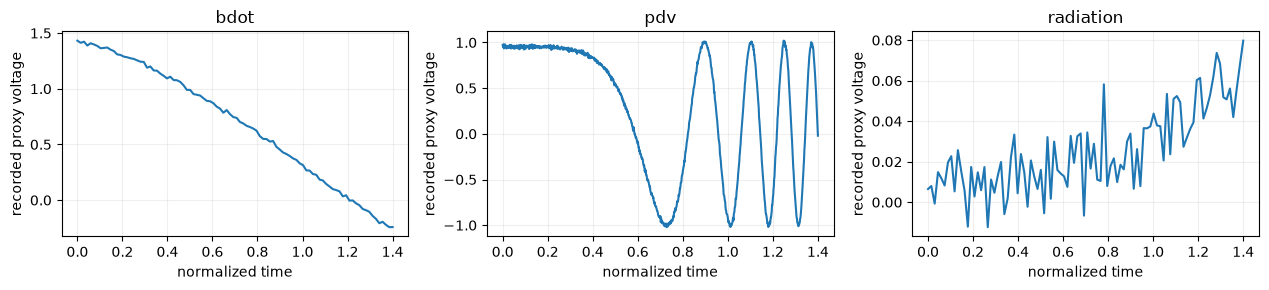

In [2]:
t,s=simulate(); cfg=DiagnosticConfig(noise=.012)
record=observe(t.numpy(),s[0].numpy(),cfg,seed=701)
raw=record['diagnostics']
print('Acquisition config:',record['acquisition'])
fig,axes=plt.subplots(1,3,figsize=(13,3))
for ax,name in zip(axes,['bdot','pdv','radiation']):
    ax.plot(raw[name]['time'],raw[name]['voltage']); ax.set(title=name,xlabel='normalized time',ylabel='recorded proxy voltage')
plt.tight_layout(); plt.show()

## 2. B-dot integration and its baseline problem
Voltage proportional to a derivative becomes current only after calibration and integration. A small constant voltage offset integrates into a ramp. These records are already synthetic gain-calibrated apart from the configured gain; the reconstruction uses the known initial current.

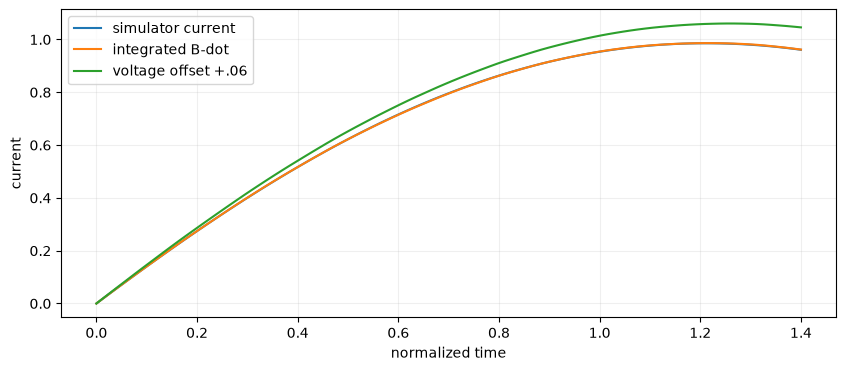

B-dot reconstruction MAE: 0.0005533655869832078


In [3]:
from scipy.integrate import cumulative_trapezoid
b=raw['bdot']; reconstructed=cumulative_trapezoid(b['voltage']/cfg.gain,b['time'],initial=0)
biased=cumulative_trapezoid((b['voltage']+.06)/cfg.gain,b['time'],initial=0)
plt.plot(t,s[0,:,1],label='simulator current'); plt.plot(t,reconstructed,label='integrated B-dot'); plt.plot(t,biased,label='voltage offset +.06')
plt.xlabel('normalized time'); plt.ylabel('current'); plt.legend(); plt.show()
bdot_error=float(np.mean(np.abs(reconstructed-s[0,:,1].numpy())))
print('B-dot reconstruction MAE:',bdot_error)

## 3. Revisit the PDV window, now in a multi-diagnostic context
For this idealized normal-incidence waveform, $f=2u/\lambda$. Real-valued cosine data gives a speed magnitude without a sign convention or extra information. Window length trades time localization against frequency resolution. The wavelength here is dimensionless. The earlier PDV notebooks remain the more detailed waveform benchmark.

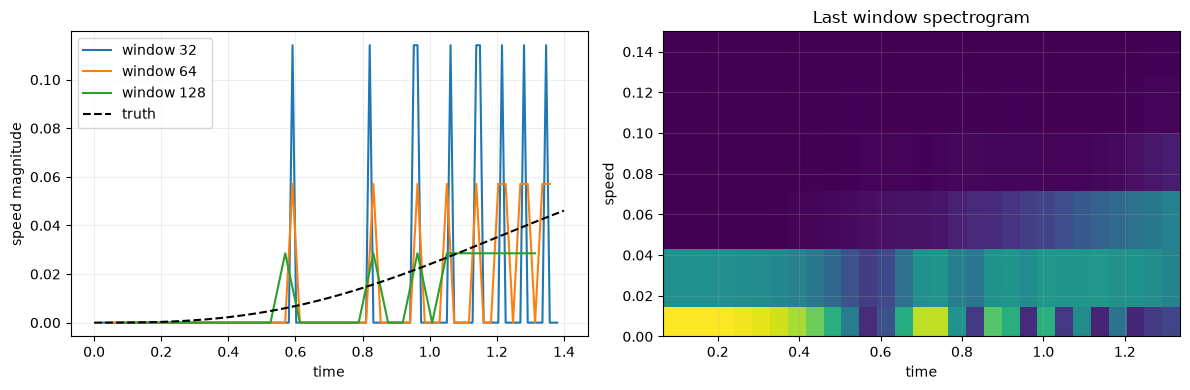

[{'window': 32, 'MAE': 0.019565588304235156},
 {'window': 64, 'MAE': 0.01378625727489834},
 {'window': 128, 'MAE': 0.007445926520634723}]

In [4]:
from scipy.signal import stft
p=raw['pdv']; fs=1/np.diff(p['time']).mean(); pdv_rows=[]
fig,axes=plt.subplots(1,2,figsize=(12,4))
for window in [32,64,128]:
    freq,frames,z=stft(p['voltage'],fs=fs,nperseg=window,noverlap=window*3//4,boundary=None,padded=False)
    ridge=freq[np.abs(z).argmax(axis=0)]*cfg.pdv_wavelength/2
    truth=np.interp(frames,t,s[0,:,3]); err=float(np.abs(ridge-truth).mean())
    pdv_rows.append({'window':window,'MAE':err})
    axes[0].plot(frames,ridge,label=f'window {window}')
axes[0].plot(t,s[0,:,3],'k--',label='truth'); axes[0].legend(); axes[0].set(xlabel='time',ylabel='speed magnitude')
axes[1].pcolormesh(frames,freq*cfg.pdv_wavelength/2,np.abs(z),shading='auto'); axes[1].set(ylim=(0,.15),xlabel='time',ylabel='speed',title='Last window spectrogram')
plt.tight_layout(); plt.show(); display(pdv_rows)

## 4. Imaging and perturbation detectability
The image contains a sinusoidal edge perturbation. We extract the positive edge at a fixed intensity threshold, then estimate the known Fourier mode. This is a deliberately simple baseline: changing blur or exposure can conceal a real perturbation. Observing a mode does not establish its mechanism.

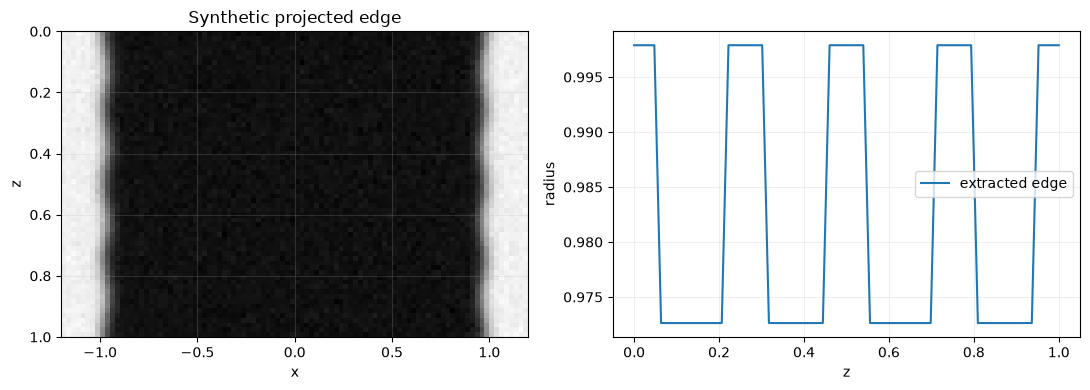

{'reconstructed_radius': 0.9826586855856585, 'mode_amplitude': 0.015107280412581841, 'simulator_amplitude_at_frame': 0.011836440739148659}


In [5]:
im=raw['image']; positive=im['x']>=0; xp=im['x'][positive]
def edge_summary(image_record):
    frame=image_record['intensity'][-1][:,positive]
    edge=xp[np.abs(frame-.675).argmin(axis=1)]
    mode=np.cos(2*np.pi*4*image_record['z'])
    design=np.stack([np.ones_like(mode),mode],axis=1)
    radius,amplitude=np.linalg.lstsq(design,edge,rcond=None)[0]
    return float(radius),float(abs(amplitude)),edge
radius,amplitude,edge=edge_summary(im)
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].imshow(im['intensity'][-1],extent=[-1.2,1.2,1,0],aspect='auto',cmap='gray'); axes[0].set(title='Synthetic projected edge',xlabel='x',ylabel='z')
axes[1].plot(im['z'],edge,label='extracted edge'); axes[1].set(xlabel='z',ylabel='radius'); axes[1].legend()
plt.tight_layout(); plt.show()
print({'reconstructed_radius':radius,'mode_amplitude':amplitude,'simulator_amplitude_at_frame':float(np.interp(im['time'][-1],t,s[0,:,5]))})

In [6]:
blur_rows=[]
for blur in [.25,1.,3.,6.]:
    observed=observe(t.numpy(),s[0].numpy(),replace(cfg,image_psf_pixels=blur),seed=702)
    rr,aa,_=edge_summary(observed['diagnostics']['image'])
    blur_rows.append({'PSF_pixels':blur,'radius':rr,'amplitude':aa})
display(blur_rows)

[{'PSF_pixels': 0.25,
  'radius': 0.9830480686110118,
  'amplitude': 0.015449924684724066},
 {'PSF_pixels': 1.0,
  'radius': 0.9826575813750352,
  'amplitude': 0.01517794989247738},
 {'PSF_pixels': 3.0,
  'radius': 0.9799462975362913,
  'amplitude': 0.01185801030894628},
 {'PSF_pixels': 6.0,
  'radius': 0.9816550453995774,
  'amplitude': 0.003550778637574736}]

### Visual lab — Blur can hide structure that is still present

All three columns observe the **same hidden shot**. Only the image point-spread width changes, with the same noise seed. The lower panels show the edge extracted by the existing threshold baseline.

**Notice:** a weak reconstructed ripple can mean poor visibility, not a stable material surface. Pixel quantization is visible in the stepped edge estimate.

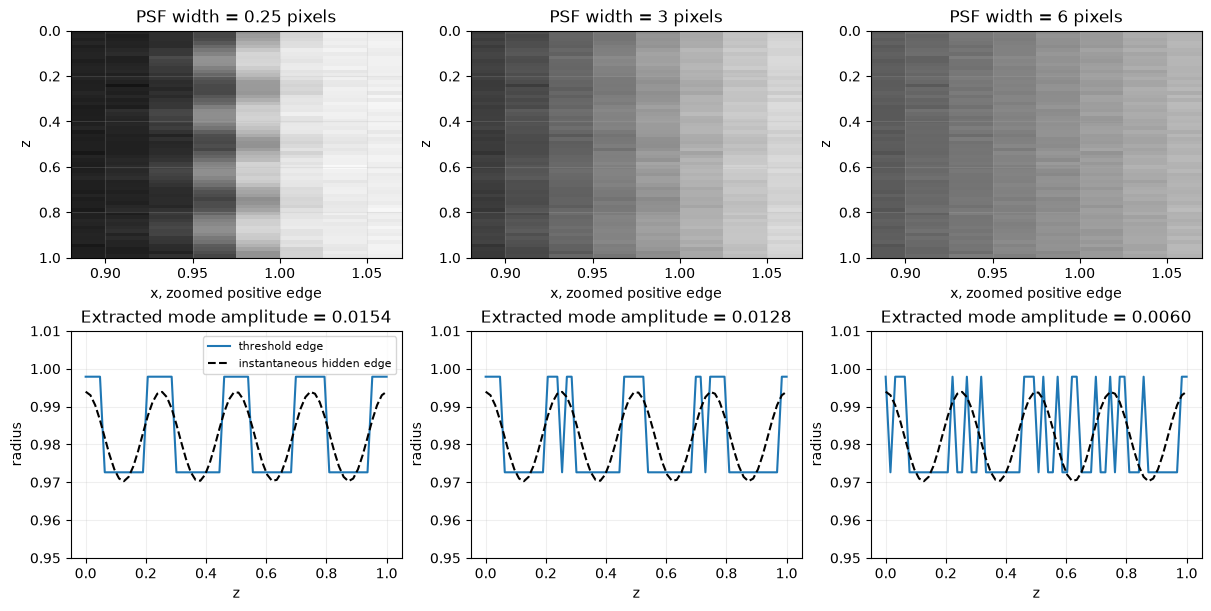

In [7]:
v_fig,v_axes=plt.subplots(2,3,figsize=(12,6),layout='constrained')
for v_j,v_blur in enumerate([.25,3.,6.]):
    v_record=observe(t.numpy(),s[0].numpy(),replace(cfg,image_psf_pixels=v_blur),seed=70707)['diagnostics']['image']
    v_radius,v_amplitude,v_edge=edge_summary(v_record)
    v_axes[0,v_j].imshow(v_record['intensity'][-1],extent=[-1.2,1.2,1,0],aspect='auto',cmap='gray',vmin=.25,vmax=1.05)
    v_axes[0,v_j].set(xlim=(.88,1.07),title=f'PSF width = {v_blur:g} pixels',xlabel='x, zoomed positive edge',ylabel='z')
    v_axes[1,v_j].plot(v_record['z'],v_edge,label='threshold edge')
    v_frame_t=v_record['time'][-1]; v_true_r=np.interp(v_frame_t,t,s[0,:,2]); v_true_a=np.interp(v_frame_t,t,s[0,:,5])
    v_axes[1,v_j].plot(v_record['z'],v_true_r+v_true_a*np.cos(8*np.pi*v_record['z']),'k--',label='instantaneous hidden edge')
    v_axes[1,v_j].set(xlabel='z',ylabel='radius',ylim=(.95,1.01),title=f'Extracted mode amplitude = {v_amplitude:.4f}')
v_axes[1,0].legend(fontsize=8); plt.show()

## 5. Radiation and spectral nuisance parameters
The same thermal proxy feeds two different observation operators. Detector response and source intensity can be confounded. The spectrum below is a Poisson-count lesson, not a physical temperature inversion. To make it physical, supply emissivity, opacity, spectral response, geometry and calibration models.

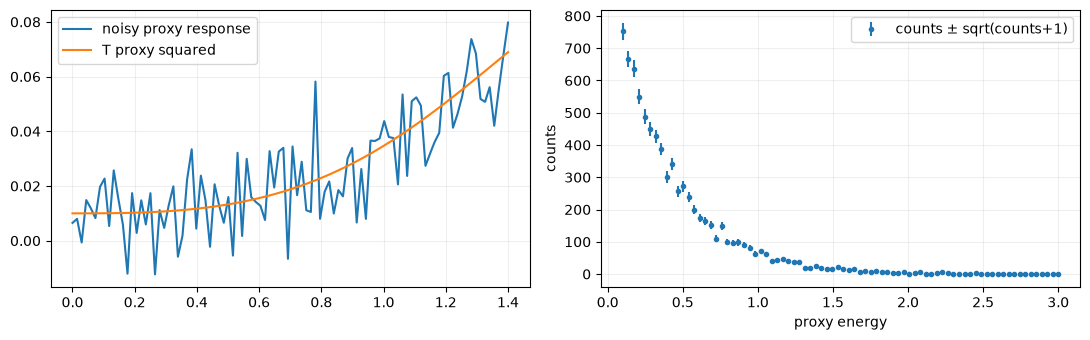

In [8]:
spec=raw['spectrum']; e=spec['energy']; c=spec['counts']
fig,axes=plt.subplots(1,2,figsize=(11,3.5))
axes[0].plot(raw['radiation']['time'],raw['radiation']['voltage'],label='noisy proxy response'); axes[0].plot(t,s[0,:,4].numpy()**2,label='T proxy squared'); axes[0].legend()
axes[1].errorbar(e,c,yerr=np.sqrt(c+1),fmt='.',label='counts ± sqrt(counts+1)'); axes[1].set(xlabel='proxy energy',ylabel='counts'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Timing is part of the measurement model
Identical states observed with an offset clock can appear to disagree. Our convention is `measurement(t) = response(state(t + clock_shift))`. Positive shift means the sampled state is later than the recorded time. Near the boundaries interpolation holds the endpoint, another explicit simplification.

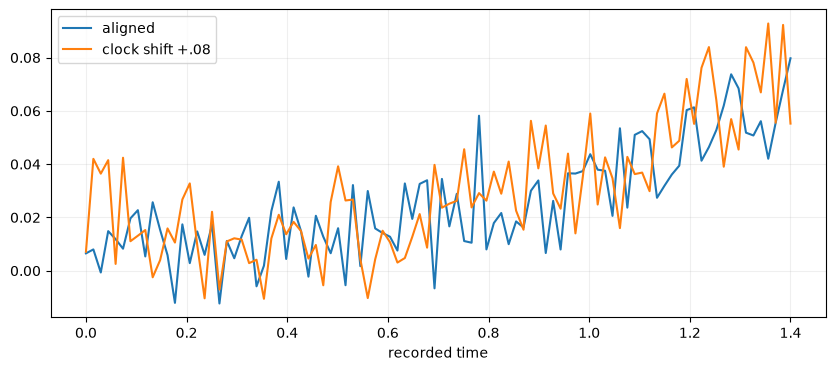

/Users/operator/Desktop/Factor/runs/world-model/07-0a5a7a4988


In [9]:
late=observe(t.numpy(),s[0].numpy(),replace(cfg,clock_shift=.08,missing=('spectrum',)),seed=703)
plt.plot(t,raw['radiation']['voltage'],label='aligned'); plt.plot(t,late['diagnostics']['radiation']['voltage'],label='clock shift +.08'); plt.xlabel('recorded time'); plt.legend(); plt.show()
assert 'spectrum' not in late['diagnostics']
run=save_run(ROOT,'07',{'bdot_MAE':bdot_error,'pdv_window_scan':pdv_rows,'image_blur_scan':blur_rows},asdict(cfg))
print(run)

### Visual lab — Distinguish a sample from an exposure

Dots indicate waveform samples, while orange bands indicate finite camera exposures. A frame summarizes an interval rather than an instant. The second row uses the shifted-clock convention from this lesson: the state is sampled at recorded time plus the clock offset.

**Predict:** which fast features could disappear when an exposure is widened?

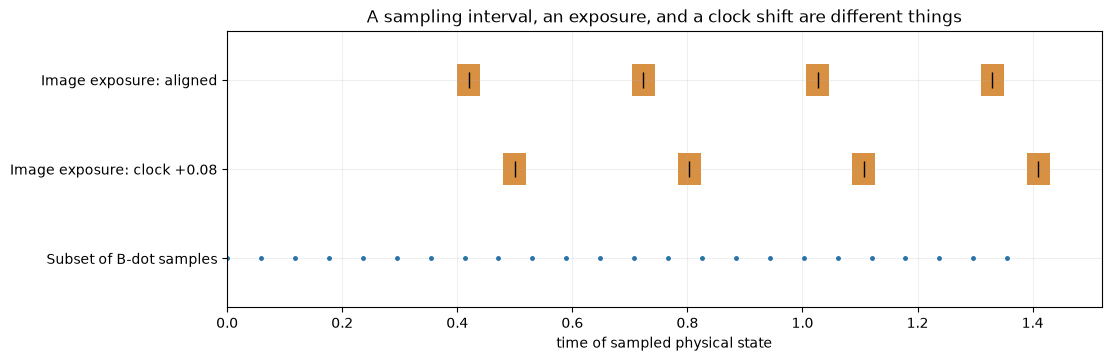

In [10]:
v_fig,v_ax=plt.subplots(figsize=(11,3.5),layout='constrained')
v_frame_times=raw['image']['time']; v_exposure=cfg.image_exposure
for v_row,v_shift,v_label in [(2,0,'Image exposure: aligned'),(1,.08,'Image exposure: clock +0.08')]:
    for v_ft in v_frame_times:
        v_ax.broken_barh([(v_ft+v_shift-v_exposure/2,v_exposure)],(v_row-.18,.36),facecolors='#d89042')
        v_ax.plot(v_ft+v_shift,v_row,'|',color='black',ms=12)
v_ax.plot(raw['bdot']['time'][::4],np.zeros_like(raw['bdot']['time'][::4]),'.',color='#2873a6',ms=5)
v_ax.set(yticks=[0,1,2],yticklabels=['Subset of B-dot samples','Image exposure: clock +0.08','Image exposure: aligned'],
         xlabel='time of sampled physical state',xlim=(0,float(t[-1])+.12),ylim=(-.55,2.55),title='A sampling interval, an exposure, and a clock shift are different things')
plt.show()

## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Add a shared clock error and independent per-channel errors. What can a timing fiducial identify?
2. Add PDV dropout or a secondary return from notebook 04 and propagate its uncertainty into a reconstruction.
3. Replace the edge proxy with a line-integrated attenuation model; document what physical inputs it requires.